In [2]:
# Upload the file
from google.colab import files
uploaded = files.upload()

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_excel('task1Data.xlsx')

# Preview the data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Saving task1Data.xlsx to task1Data (2).xlsx
Shape: (909, 9)

First 5 rows:


,Sales_ID,Salesperson,Product,Province,Customer,Date,Item Cost,No.Items [Quantity],Total Sales
0,Mallo68,"Malloy, Terri",Media Armoire,WC,B&B Spaces,2018-07-31,272.760,12,3273.120
1,Ramey433,"Ramey, Sam",Bamboo End Table,NC,Home Emporium,2019-07-19,63.992,3,191.976
2,"Owen,566","Owen, Robert",Bamboo Coffee Table,WC,Home Emporium,2019-02-03,135.160,13,1757.080
3,Warre166,"Warren, Leonard",Captain RecliNCr,NW,Home Emporium,2019-04-02,272.760,4,1091.040
4,Lucas737,"Lucas, John",Captain RecliNCr,WC,Fabulous Homes,2019-07-25,272.760,6,1636.560


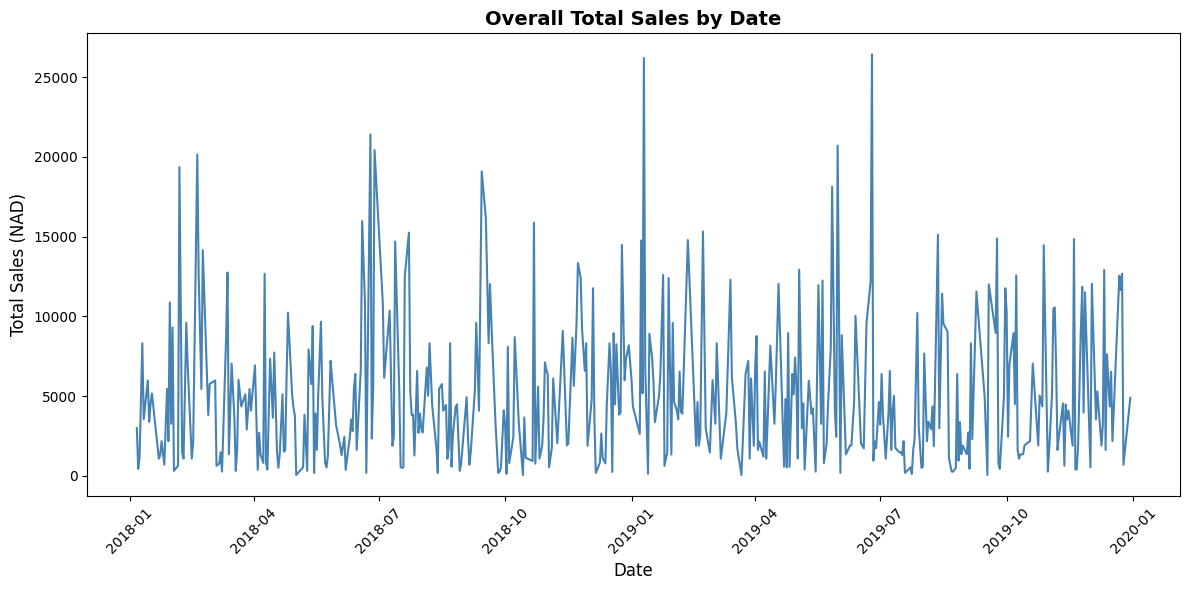

In [4]:
# Task 1(c) - Time-series of overall sales by date

df['Date'] = pd.to_datetime(df['Date'])
daily_sales = df.groupby('Date')['Total Sales'].sum()

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.values, color='steelblue', linewidth=1.5)
plt.title('Overall Total Sales by Date', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales (NAD)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('task1c_timeseries.png', dpi=150)
plt.show()

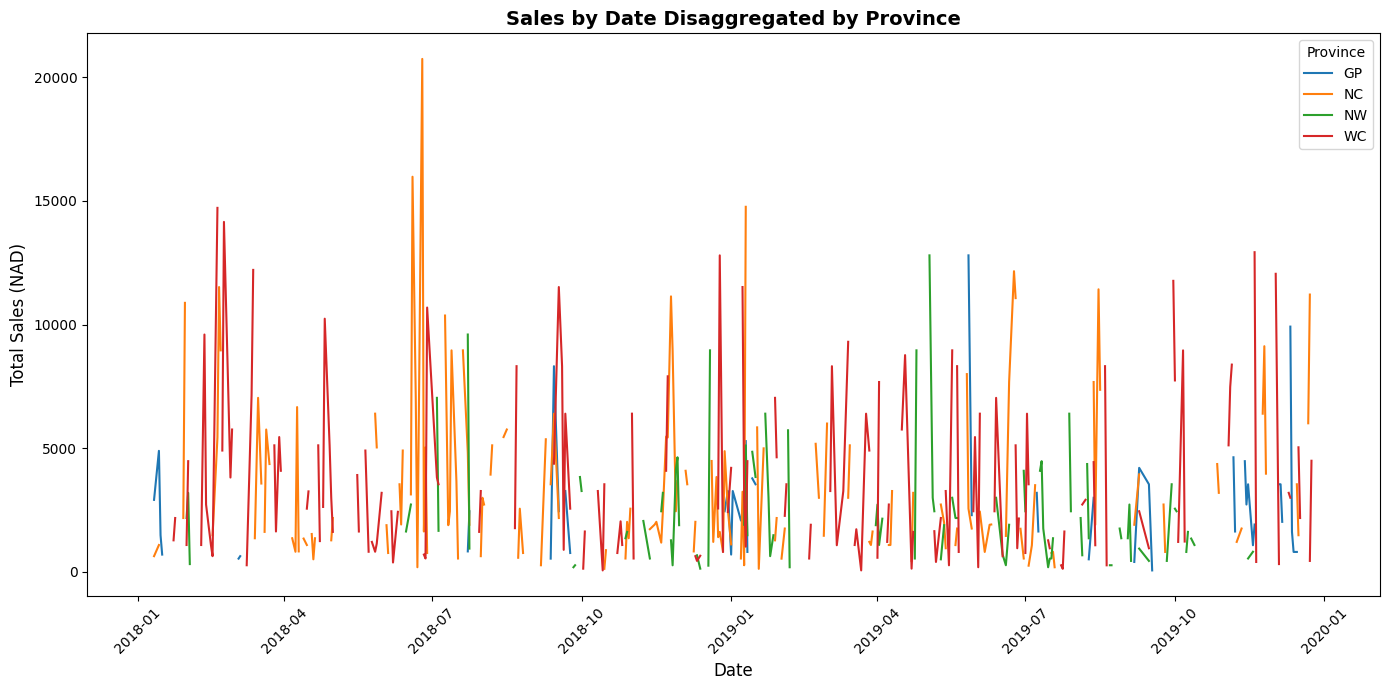

In [5]:
# Task 1(d) - Disaggregated time-series by Province

province_date = df.groupby(['Date', 'Province'])['Total Sales'].sum().unstack()

plt.figure(figsize=(14, 7))
for province in province_date.columns:
    plt.plot(province_date.index, province_date[province], label=province, linewidth=1.5)

plt.title('Sales by Date Disaggregated by Province', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales (NAD)', fontsize=12)
plt.legend(title='Province')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('task1d_province_timeseries.png', dpi=150)
plt.show()

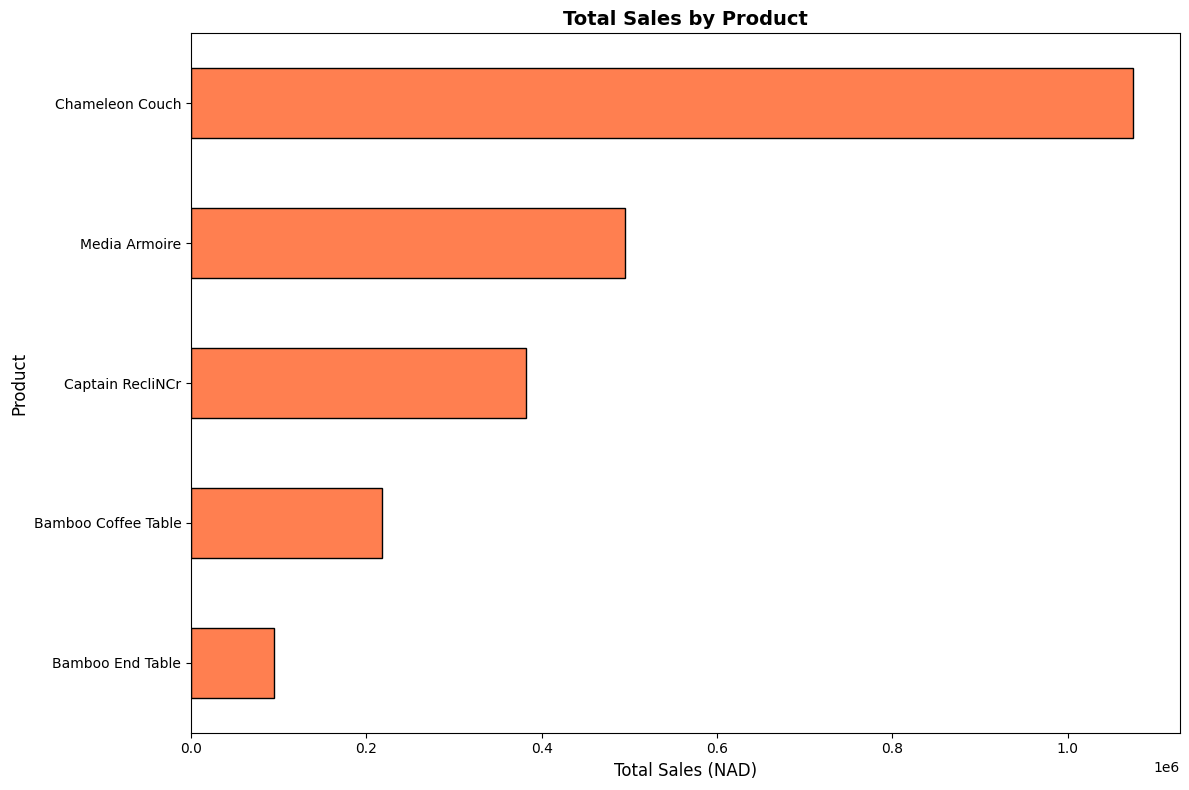

In [6]:
# Task 1(f) - Visualisation 1: Total Sales by Product

product_sales = df.groupby('Product')['Total Sales'].sum().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
product_sales.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Total Sales by Product', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales (NAD)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.tight_layout()
plt.savefig('task1f_product_sales.png', dpi=150)
plt.show()

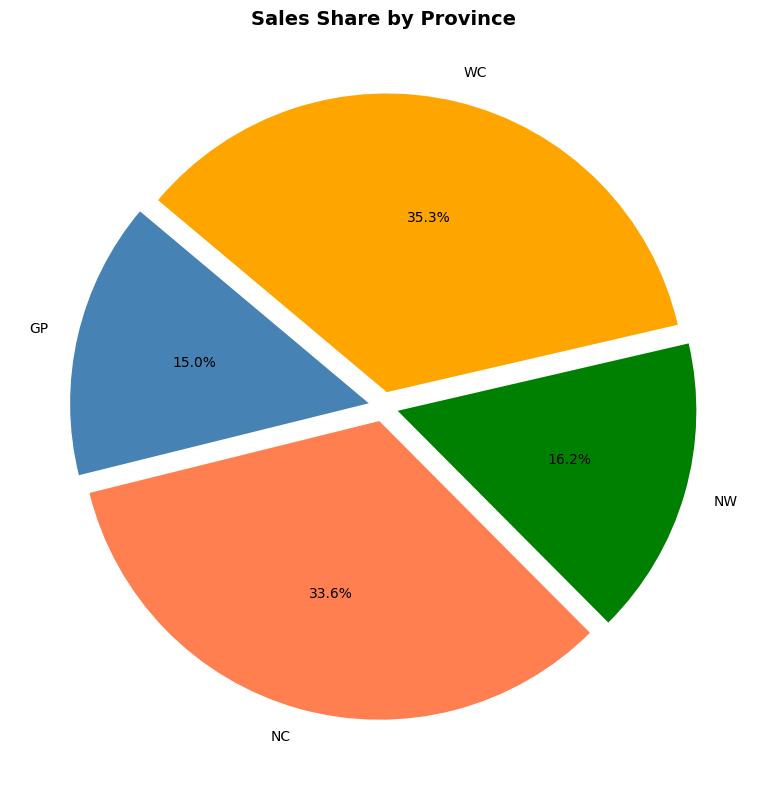

In [7]:
# Task 1(f) - Visualisation 2: Sales share by Province (Pie chart)

province_sales = df.groupby('Province')['Total Sales'].sum()

plt.figure(figsize=(8, 8))
plt.pie(province_sales.values,
        labels=province_sales.index,
        autopct='%1.1f%%',
        colors=['steelblue','coral','green','orange'],
        startangle=140,
        explode=(0.05, 0.05, 0.05, 0.05))
plt.title('Sales Share by Province', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task1f_province_pie.png', dpi=150)
plt.show()

<Figure size 1000x600 with 0 Axes>

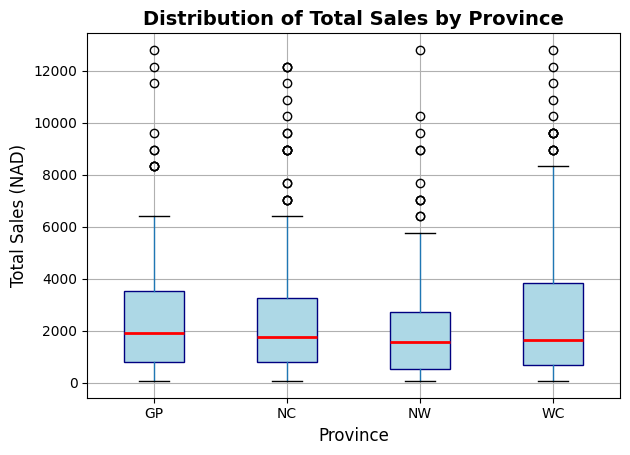

In [8]:
# Task 1(f) - Visualisation 3: Box plot of Total Sales by Province

plt.figure(figsize=(10, 6))
df.boxplot(column='Total Sales', by='Province',
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2))
plt.title('Distribution of Total Sales by Province', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Province', fontsize=12)
plt.ylabel('Total Sales (NAD)', fontsize=12)
plt.tight_layout()
plt.savefig('task1f_boxplot.png', dpi=150)
plt.show()

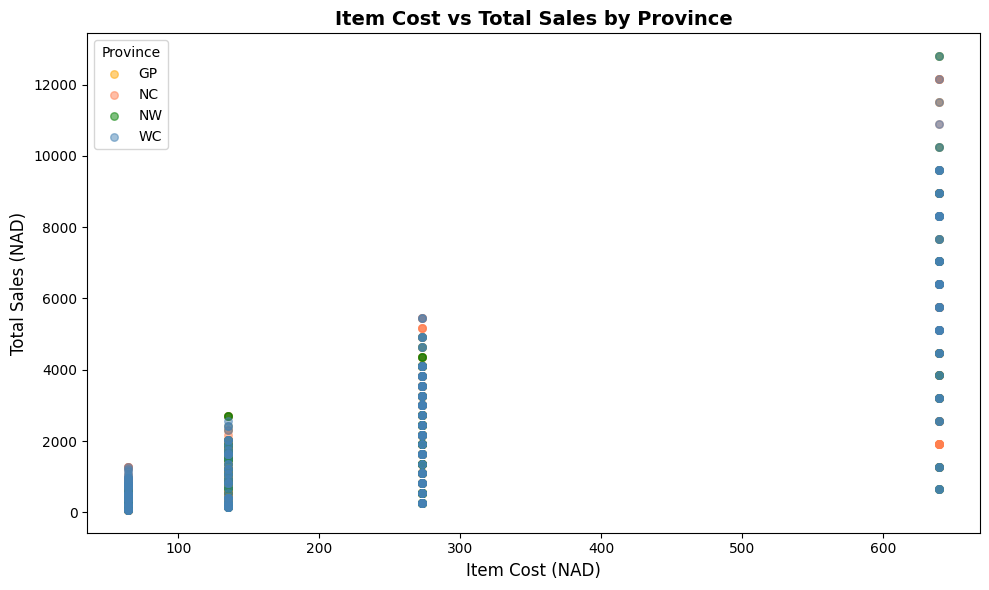

In [9]:
# Task 1(f) - Visualisation 4: Scatter plot - Item Cost vs Total Sales

plt.figure(figsize=(10, 6))
colors = {'WC':'steelblue', 'NC':'coral', 'NW':'green', 'GP':'orange'}
for province, group in df.groupby('Province'):
    plt.scatter(group['Item Cost'], group['Total Sales'],
                label=province, alpha=0.5, s=30,
                color=colors[province])

plt.title('Item Cost vs Total Sales by Province', fontsize=14, fontweight='bold')
plt.xlabel('Item Cost (NAD)', fontsize=12)
plt.ylabel('Total Sales (NAD)', fontsize=12)
plt.legend(title='Province')
plt.tight_layout()
plt.savefig('task1f_scatter.png', dpi=150)
plt.show()

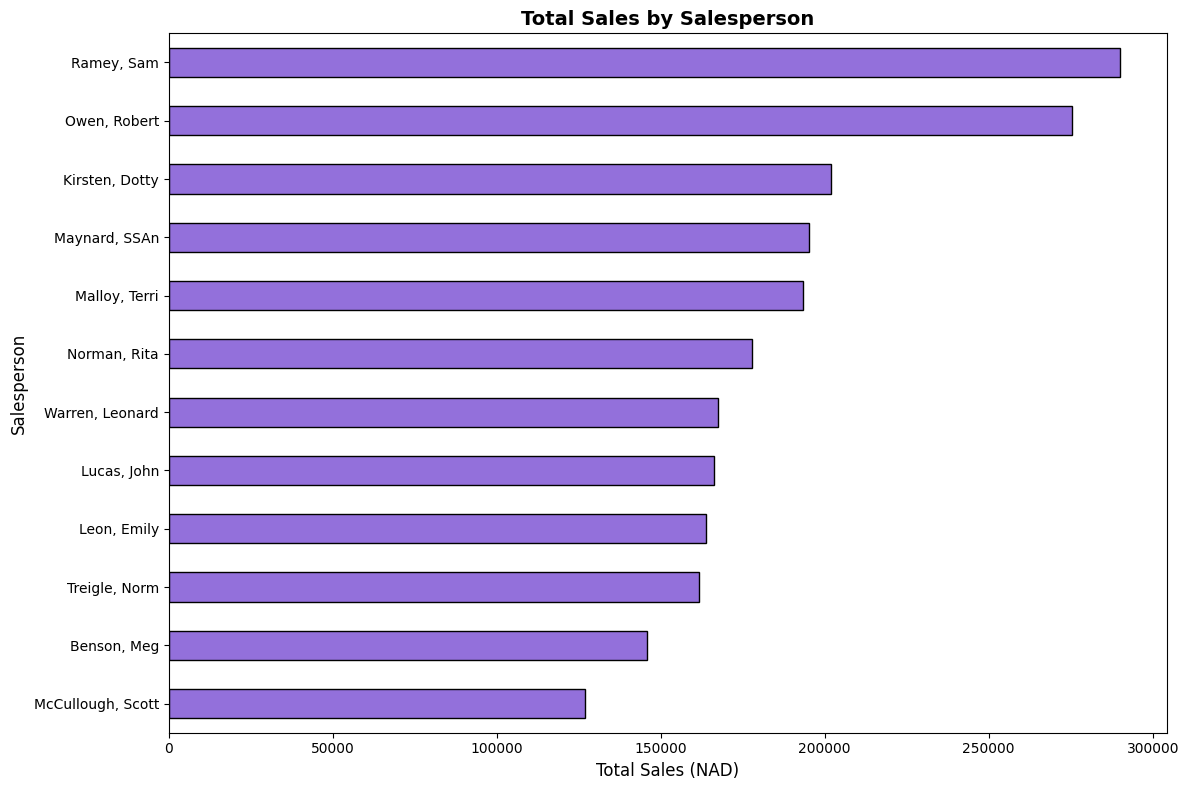

In [10]:
# Task 1(f) - Visualisation 5: Total Sales by Salesperson

salesperson_sales = df.groupby('Salesperson')['Total Sales'].sum().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
salesperson_sales.plot(kind='barh', color='mediumpurple', edgecolor='black')
plt.title('Total Sales by Salesperson', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales (NAD)', fontsize=12)
plt.ylabel('Salesperson', fontsize=12)
plt.tight_layout()
plt.savefig('task1f_salesperson.png', dpi=150)
plt.show()

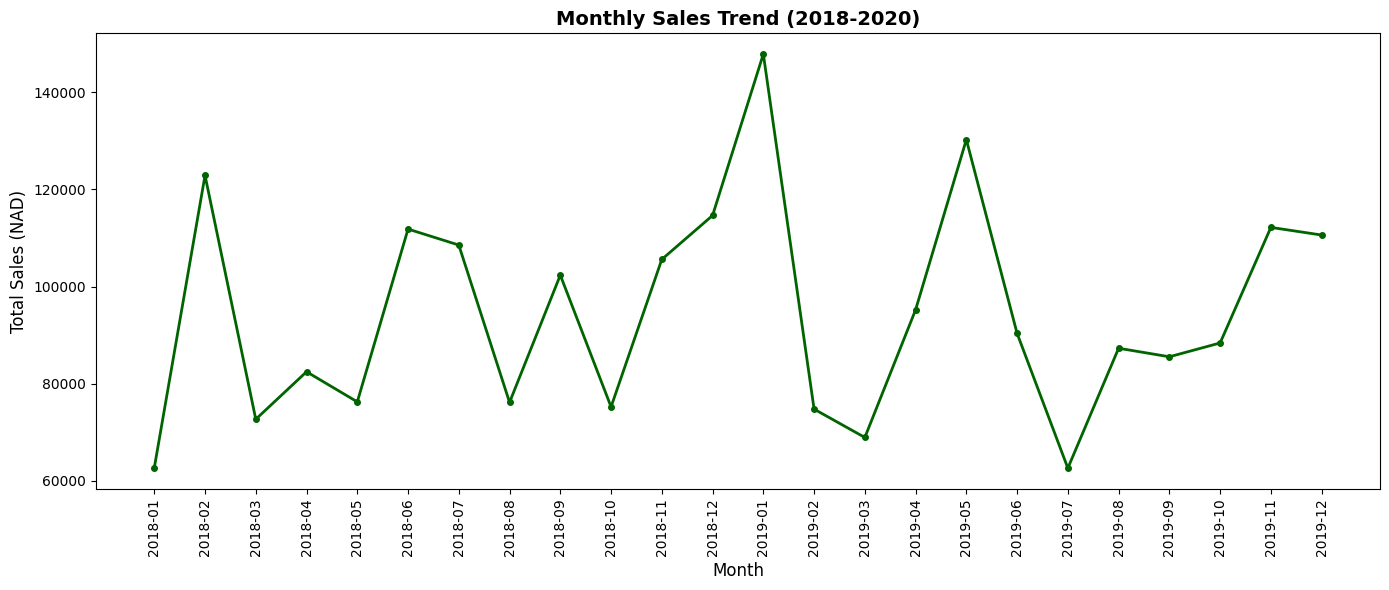

In [12]:
# Task 1(f) - Visualisation 6: Monthly Sales Trend

df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total Sales'].sum()

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values,
         color='darkgreen', linewidth=2, marker='o', markersize=4)
plt.title('Monthly Sales Trend (2018-2020)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales (NAD)', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('task1f_monthly_trend.png', dpi=150)
plt.show()

In [13]:
from google.colab import files

files.download('task1b_province_sales.png')
files.download('task1c_timeseries.png')
files.download('task1d_province_timeseries.png')
files.download('task1f_product_sales.png')
files.download('task1f_province_pie.png')
files.download('task1f_boxplot.png')
files.download('task1f_scatter.png')
files.download('task1f_salesperson.png')
files.download('task1f_monthly_trend.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# Task 2 - Upload and read task2Data.csv
from google.colab import files
uploaded = files.upload()

import pandas as pd

df2 = pd.read_csv('task2Data.csv')
print("Shape:", df2.shape)
print("\nFirst 5 rows:")
print(df2.head())
print("\nValue counts - Actual Condition:")
print(df2['Actual_Condition'].value_counts())
print("\nValue counts - Test Result:")
print(df2['Test_Result'].value_counts())
print("\nCrosstab:")
print(pd.crosstab(df2['Actual_Condition'], df2['Test_Result']))

Saving task2Data.csv to task2Data.csv
Shape: (4000, 3)

First 5 rows:
   ID Actual_Condition Test_Result
0   0        TB_Absent    Negative
1   1        TB_Absent    Negative
2   2        TB_Absent    Negative
3   3        TB_Absent    Negative
4   4        TB_Absent    Negative

Value counts - Actual Condition:
Actual_Condition
TB_Absent     3980
TB_Present      20
Name: count, dtype: int64

Value counts - Test Result:
Test_Result
Negative    3783
Positive     217
Name: count, dtype: int64

Crosstab:
Test_Result       Negative  Positive
Actual_Condition                    
TB_Absent             3781       199
TB_Present               2        18


In [15]:
# Task 2 - Bayes Theorem Calculation

# From crosstab
TB_Absent_Neg = 3781
TB_Absent_Pos = 199
TB_Present_Neg = 2
TB_Present_Pos = 18
total = 4000

# Priors
P_Absent = 3980/4000
P_Present = 20/4000

# Likelihoods
P_Neg_given_Absent = TB_Absent_Neg / 3980
P_Neg_given_Present = TB_Present_Neg / 20

# Total probability of Negative
P_Neg = (P_Absent * P_Neg_given_Absent) + (P_Present * P_Neg_given_Present)

# Bayes Theorem
P_Absent_given_Neg = (P_Absent * P_Neg_given_Absent) / P_Neg

print("P(TB_Absent):", round(P_Absent, 4))
print("P(TB_Present):", round(P_Present, 4))
print("P(Neg|TB_Absent):", round(P_Neg_given_Absent, 4))
print("P(Neg|TB_Present):", round(P_Neg_given_Present, 4))
print("P(Negative):", round(P_Neg, 4))
print("\nP(TB_Absent | Negative):", round(P_Absent_given_Neg, 4))
print("As percentage:", round(P_Absent_given_Neg * 100, 2), "%")

P(TB_Absent): 0.995
P(TB_Present): 0.005
P(Neg|TB_Absent): 0.95
P(Neg|TB_Present): 0.1
P(Negative): 0.9457

P(TB_Absent | Negative): 0.9995
As percentage: 99.95 %


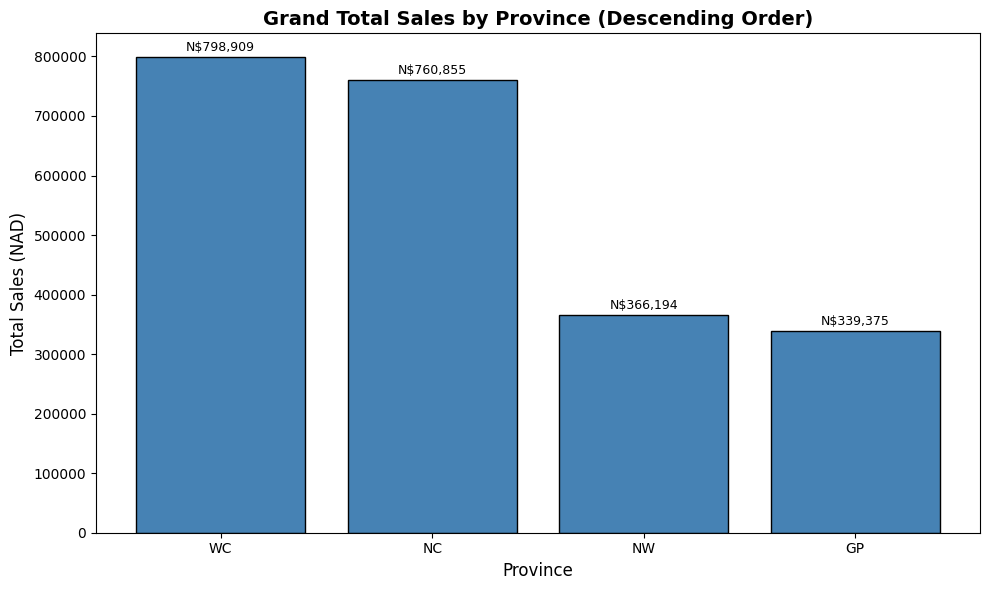

Province Sales:
 Province
WC    798909.048
NC    760854.760
NW    366194.000
GP    339374.728
Name: Total Sales, dtype: float64


In [3]:
# Task 1(b) - Grand total sales per province (descending order)

province_sales = df.groupby('Province')['Total Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(province_sales.index, province_sales.values, color='steelblue', edgecolor='black')

# Add value labels on top of each bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5000,
             f'N${bar.get_height():,.0f}',
             ha='center', va='bottom', fontsize=9)

plt.title('Grand Total Sales by Province (Descending Order)', fontsize=14, fontweight='bold')
plt.xlabel('Province', fontsize=12)
plt.ylabel('Total Sales (NAD)', fontsize=12)
plt.tight_layout()
plt.savefig('task1b_province_sales.png', dpi=150)
plt.show()
print("Province Sales:\n", province_sales)